# 🔬 Classification de Lésions Cutanées — HAM10000
## Pipeline Deep Learning : Simple CNN vs ResNet50

**Dataset :** HAM10000 (10 015 images, 7 classes)  
**Objectif :** Comparer un CNN simple (from scratch) à ResNet50 (transfer learning)  
**Pipeline :** Prétraitement → Augmentation → Entraînement → Évaluation → Interprétation (Grad-CAM)

---


## 📁 Cellule 1 — Copie des images

In [1]:
# Cellule: Installation et téléchargement via KaggleHub
!pip install kagglehub -q

import kagglehub
import os
import shutil
import glob

print("Téléchargement du dataset HAM10000 via KaggleHub...")
print("-" * 50)

# Télécharger le dataset
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print(f"✓ Dataset téléchargé dans: {path}")

# Créer le dossier cible
os.makedirs('/content/skin_data/images', exist_ok=True)

# Trouver et copier les images
print("\nRecherche des images...")
image_count = 0

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.jpg'):
            src = os.path.join(root, file)
            dst = os.path.join('/content/skin_data/images', file)
            shutil.copy2(src, dst)
            image_count += 1

# Copier les métadonnées
for root, dirs, files in os.walk(path):
    for file in files:
        if file == 'HAM10000_metadata.csv':
            shutil.copy2(os.path.join(root, file), '/content/skin_data/')
            print("✓ Métadonnées copiées")
            break

print(f"\n✅ {image_count} images copiées dans /content/skin_data/images/")

# Vérification
images = glob.glob('/content/skin_data/images/*.jpg')
print(f"📊 {len(images)} images disponibles")

Téléchargement du dataset HAM10000 via KaggleHub...
--------------------------------------------------
Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
✓ Dataset téléchargé dans: /kaggle/input/skin-cancer-mnist-ham10000

Recherche des images...
✓ Métadonnées copiées

✅ 20030 images copiées dans /content/skin_data/images/
📊 10015 images disponibles


In [2]:
import os
import glob
import shutil

source_dir_1 = '/content/skin_data/HAM10000_images_part_1'
source_dir_2 = '/content/skin_data/HAM10000_images_part_2'
os.makedirs('/content/skin_data/images', exist_ok=True)

print("📂 Déplacement des images...")
for src in [source_dir_1, source_dir_2]:
    if os.path.exists(src) and os.path.isdir(src):
        for img in glob.glob(f'{src}/*.jpg'):
            shutil.copy(img, '/content/skin_data/images/')
        print(f"  ✓ Copié depuis {src}")

images = glob.glob('/content/skin_data/images/*.jpg')
print(f"\n✅ {len(images)} images disponibles")

📂 Déplacement des images...

✅ 10015 images disponibles


## 📦 Cellule 2 — Imports & Configuration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from pathlib import Path
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc)
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils.class_weight import compute_class_weight

plt.style.use('seaborn-v0_8')
%matplotlib inline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

🖥️  Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


## 📊 Cellule 3 — Analyse Exploratoire des Données

Total dans metadata: 10015
Dataset final: 10015 images

📊 Distribution des classes:
  Nævus mélanocytaire            (nv):  6705  ██████████████████████████ 66.9%
  Mélanome                       (mel):  1113  ████ 11.1%
  Kératose bénigne               (bkl):  1099  ████ 11.0%
  Carcinome basocellulaire       (bcc):   514  ██ 5.1%
  Kératose actinique             (akiec):   327  █ 3.3%
  Lésions vasculaires            (vasc):   142   1.4%
  Dermatofibrome                 (df):   115   1.1%


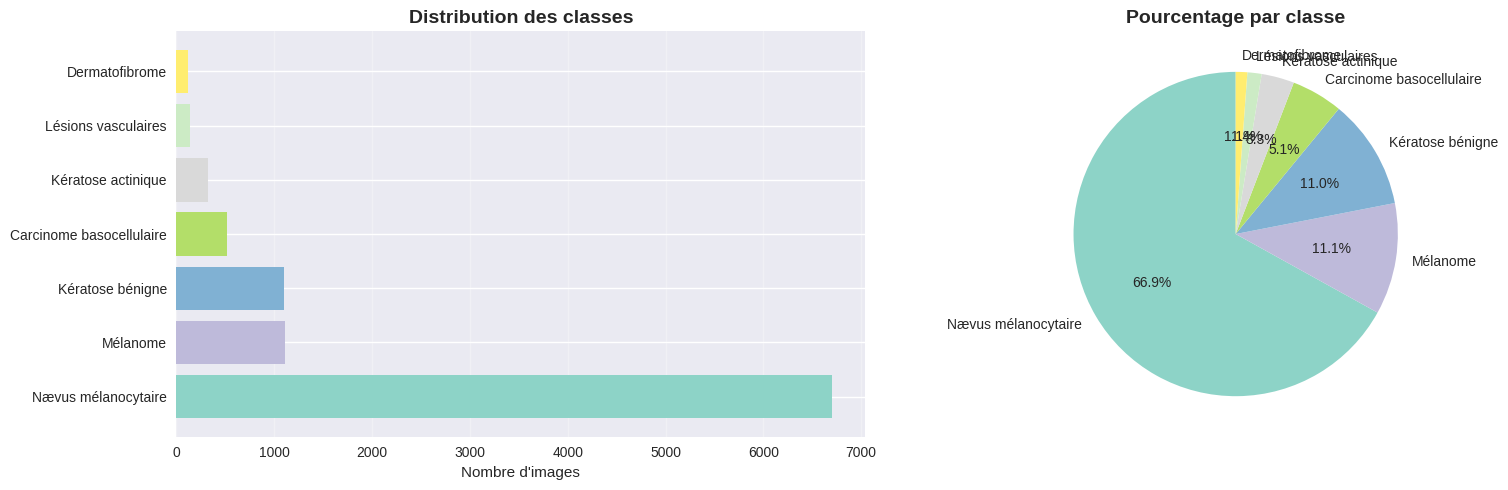

In [4]:
metadata = pd.read_csv('/content/skin_data/HAM10000_metadata.csv')
print(f"Total dans metadata: {len(metadata)}")

existing_images = set([
    os.path.basename(f).replace('.jpg', '')
    for f in glob.glob('/content/skin_data/images/*.jpg')
])
metadata['exists'] = metadata['image_id'].isin(existing_images)
metadata = metadata[metadata['exists']].reset_index(drop=True)
print(f"Dataset final: {len(metadata)} images")

CLASS_NAMES_FR = {
    'akiec': 'Kératose actinique',
    'bcc':   'Carcinome basocellulaire',
    'bkl':   'Kératose bénigne',
    'df':    'Dermatofibrome',
    'mel':   'Mélanome',
    'nv':    'Nævus mélanocytaire',
    'vasc':  'Lésions vasculaires'
}

class_counts = metadata['dx'].value_counts()
print("\n📊 Distribution des classes:")
for dx, count in class_counts.items():
    bar = '█' * int(count / len(metadata) * 40)
    print(f"  {CLASS_NAMES_FR[dx]:30s} ({dx}): {count:5d}  {bar} {count/len(metadata)*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = plt.cm.Set3(np.linspace(0, 1, len(class_counts)))

axes[0].barh(
    [CLASS_NAMES_FR[dx] for dx in class_counts.index],
    class_counts.values, color=colors
)
axes[0].set_title('Distribution des classes', fontsize=14, fontweight='bold')
axes[0].set_xlabel("Nombre d'images")
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].pie(
    class_counts.values,
    labels=[CLASS_NAMES_FR[dx] for dx in class_counts.index],
    autopct='%1.1f%%', startangle=90, colors=colors
)
axes[1].set_title('Pourcentage par classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔄 Cellule 4 — Dataset & DataLoaders (Optimisé)

**Améliorations clés :**
- `WeightedRandomSampler` → batches rééquilibrés (combat le déséquilibre de classes)
- CNN réduit à **128×128** → 3× plus rapide à entraîner
- `pin_memory=True` → transfert GPU accéléré


In [5]:
class SkinLesionDataset(Dataset):
    def __init__(self, metadata, img_dir, transform=None):
        self.metadata = metadata.reset_index(drop=True)
        self.img_dir  = Path(img_dir)
        self.transform = transform
        self.label_encoder = LabelEncoder()
        self.labels = self.label_encoder.fit_transform(metadata['dx'])
        self.class_names = self.label_encoder.classes_

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        img_id   = self.metadata.loc[idx, 'image_id']
        img_path = self.img_dir / f"{img_id}.jpg"
        image = cv2.imread(str(img_path))
        image = np.zeros((224, 224, 3), dtype=np.uint8) if image is None \
                else cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


# ── Transforms ─────────────────────────────────────────────────────────────
# ResNet : 224×224, augmentation complète
train_transform_resnet = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# CNN simple : 128×128, augmentation légère → 3× plus rapide
train_transform_cnn = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform_resnet = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform_cnn = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


# ── Split stratifié 70/15/15 ───────────────────────────────────────────────
train_meta, temp_meta = train_test_split(
    metadata, test_size=0.30, random_state=42, stratify=metadata['dx'])
val_meta, test_meta = train_test_split(
    temp_meta, test_size=0.50, random_state=42, stratify=temp_meta['dx'])

print(f"✅ Train:      {len(train_meta)} images")
print(f"✅ Validation: {len(val_meta)} images")
print(f"✅ Test:       {len(test_meta)} images")


# ── Poids de classes & WeightedRandomSampler ───────────────────────────────
le = LabelEncoder()
le.fit(metadata['dx'])
train_labels = le.transform(train_meta['dx'])
class_names  = le.classes_

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

sample_weights = [class_weights[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

print("\n📊 Poids des classes:")
for i, cn in enumerate(class_names):
    print(f"  {CLASS_NAMES_FR[cn]:30s}: {class_weights[i]:.3f}")


# ── Datasets & DataLoaders ─────────────────────────────────────────────────
IMG_DIR  = '/content/skin_data/images'
BATCH    = 32
DL_KWARGS = dict(num_workers=2, pin_memory=True)

train_ds_cnn    = SkinLesionDataset(train_meta, IMG_DIR, train_transform_cnn)
val_ds_cnn      = SkinLesionDataset(val_meta,   IMG_DIR, val_transform_cnn)
test_ds_cnn     = SkinLesionDataset(test_meta,  IMG_DIR, val_transform_cnn)

train_ds_resnet = SkinLesionDataset(train_meta, IMG_DIR, train_transform_resnet)
val_ds_resnet   = SkinLesionDataset(val_meta,   IMG_DIR, val_transform_resnet)
test_ds_resnet  = SkinLesionDataset(test_meta,  IMG_DIR, val_transform_resnet)

train_loader_cnn    = DataLoader(train_ds_cnn,    batch_size=BATCH, sampler=sampler,  **DL_KWARGS)
val_loader_cnn      = DataLoader(val_ds_cnn,      batch_size=BATCH, shuffle=False,    **DL_KWARGS)
test_loader_cnn     = DataLoader(test_ds_cnn,     batch_size=BATCH, shuffle=False,    **DL_KWARGS)

train_loader_resnet = DataLoader(train_ds_resnet, batch_size=BATCH, sampler=sampler,  **DL_KWARGS)
val_loader_resnet   = DataLoader(val_ds_resnet,   batch_size=BATCH, shuffle=False,    **DL_KWARGS)
test_loader_resnet  = DataLoader(test_ds_resnet,  batch_size=BATCH, shuffle=False,    **DL_KWARGS)

print("\n✅ DataLoaders prêts!")

✅ Train:      7010 images
✅ Validation: 1502 images
✅ Test:       1503 images

📊 Poids des classes:
  Kératose actinique            : 4.373
  Carcinome basocellulaire      : 2.782
  Kératose bénigne              : 1.302
  Dermatofibrome                : 12.363
  Mélanome                      : 1.286
  Nævus mélanocytaire           : 0.213
  Lésions vasculaires           : 10.115

✅ DataLoaders prêts!


## 🏗️ Cellule 5 — Définition des Architectures

### Simple CNN
4 blocs Conv-BN-ReLU-Pool + classifieur FC. Entrée **128×128**.

### ResNet50
Pré-entraîné ImageNet. Toutes les couches gelées sauf le classifieur personnalisé.  
Méthode `unfreeze_layer4()` pour le fine-tuning progressif en phase 2.


In [6]:
# ── Simple CNN (entrée 128×128) ────────────────────────────────────────────
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.4), nn.Linear(256, 128), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))


# ── ResNet50 avec fine-tuning progressif ────────────────────────────────────
class ResNet50SkinCancer(nn.Module):
    def __init__(self, num_classes=7, dropout_rate=0.5):
        super().__init__()
        self.resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Geler tout
        for p in self.resnet.parameters():
            p.requires_grad = False

        # Remplacer le classifieur
        num_feat = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(num_feat, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def unfreeze_layer4(self):
        """Dégeler layer4 pour le fine-tuning phase 2."""
        for p in self.resnet.layer4.parameters():
            p.requires_grad = True

    def forward(self, x):
        return self.resnet(x)


# ── Instanciation ───────────────────────────────────────────────────────────
simple_cnn = SimpleCNN(num_classes=7).to(device)
resnet50   = ResNet50SkinCancer(num_classes=7).to(device)

def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

cnn_total,    cnn_train    = count_params(simple_cnn)
resnet_total, resnet_train = count_params(resnet50)

print("=" * 55)
print("📊 COMPARAISON DES ARCHITECTURES")
print("=" * 55)
print(f"{'Modèle':<20} {'Total':>12} {'Entraînable':>12}")
print("-" * 55)
print(f"{'Simple CNN':<20} {cnn_total:>12,} {cnn_train:>12,}")
print(f"{'ResNet50':<20} {resnet_total:>12,} {resnet_train:>12,}")
print("=" * 55)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 118MB/s]


📊 COMPARAISON DES ARCHITECTURES
Modèle                      Total  Entraînable
-------------------------------------------------------
Simple CNN                423,175      423,175
ResNet50               24,691,783    1,183,751


## 🛠️ Cellule 6 — Utilitaires d'Entraînement

- **EarlyStopping** : arrêt si la val loss ne s'améliore pas pendant `patience` epochs
- **train_one_epoch_v2** : boucle optimisée (pas de double forward)
- **evaluate** : retourne loss, accuracy, preds, labels, probs (pour ROC)
- **plot_curves** : courbes de loss et accuracy train/val


In [7]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


def train_one_epoch_v2(model, loader, criterion, optimizer, scheduler=None):
    """Boucle d'entraînement optimisée (un seul forward pass)."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, desc='  Train', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if scheduler and isinstance(scheduler, optim.lr_scheduler.OneCycleLR):
            scheduler.step()
        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), 100 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Évaluation complète : retourne loss, acc, preds, labels, probs."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for images, labels in tqdm(loader, desc='  Eval ', leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        probs   = torch.softmax(outputs, dim=1)
        total_loss += loss.item()
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return (total_loss / len(loader),
            100 * correct / total,
            np.array(all_preds),
            np.array(all_labels),
            np.array(all_probs))


def plot_curves(train_losses, val_losses, train_accs, val_accs, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(train_losses) + 1)
    ax1.plot(epochs, train_losses, 'b-o', label='Train',      linewidth=2)
    ax1.plot(epochs, val_losses,   'r-o', label='Validation', linewidth=2)
    ax1.set_title(f'Loss — {title}', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, train_accs, 'b-o', label='Train',      linewidth=2)
    ax2.plot(epochs, val_accs,   'r-o', label='Validation', linewidth=2)
    ax2.set_title(f'Accuracy — {title}', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'curves_{title.replace(" ", "_")}.png', dpi=150)
    plt.show()

print("✅ Utilitaires définis.")

✅ Utilitaires définis.


## 🔷 Cellule 7 — Entraînement Simple CNN

**Hyperparamètres :**
- Optimiseur : AdamW (`lr=3e-4`, `weight_decay=1e-3`)
- Scheduler : OneCycleLR (`max_lr=1e-3`)
- Early stopping : patience = 5
- Loss : CrossEntropyLoss pondérée


🔷 ENTRAÎNEMENT SIMPLE CNN

Epoch 1/10  |  LR: 0.000040


  Train → Loss: 1.5061  Acc: 20.87%
  Val   → Loss: 2.1430  Acc: 2.60%
  ✅ Nouveau meilleur CNN: 2.60%

Epoch 2/10  |  LR: 0.000281


  Train → Loss: 1.0827  Acc: 30.21%
  Val   → Loss: 2.5568  Acc: 4.73%
  ✅ Nouveau meilleur CNN: 4.73%

Epoch 3/10  |  LR: 0.000761


  Train → Loss: 0.9753  Acc: 36.56%
  Val   → Loss: 1.8753  Acc: 11.12%
  ✅ Nouveau meilleur CNN: 11.12%

Epoch 4/10  |  LR: 0.001000


  Train → Loss: 0.8542  Acc: 41.00%
  Val   → Loss: 1.7370  Acc: 14.31%
  ✅ Nouveau meilleur CNN: 14.31%

Epoch 5/10  |  LR: 0.000950


...

  Train → Loss: 0.6441  Acc: 49.51%
  Val   → Loss: 1.7001  Acc: 15.65%

Epoch 7/10  |  LR: 0.000610


  Train → Loss: 0.5997  Acc: 52.34%
  Val   → Loss: 1.5907  Acc: 19.44%
  ✅ Nouveau meilleur CNN: 19.44%

Epoch 8/10  |  LR: 0.000388


  Train → Loss: 0.5432  Acc: 55.79%
  Val   → Loss: 1.3680  Acc: 30.96%
  ✅ Nouveau meilleur CNN: 30.96%

Epoch 9/10  |  LR: 0.000187


  Train → Loss: 0.5099  Acc: 56.78%
  Val   → Loss: 1.3327  Acc: 34.49%
  ✅ Nouveau meilleur CNN: 34.49%

Epoch 10/10  |  LR: 0.000049


  Train → Loss: 0.4974  Acc: 58.07%
  Val   → Loss: 1.3258  Acc: 36.02%
  ✅ Nouveau meilleur CNN: 36.02%


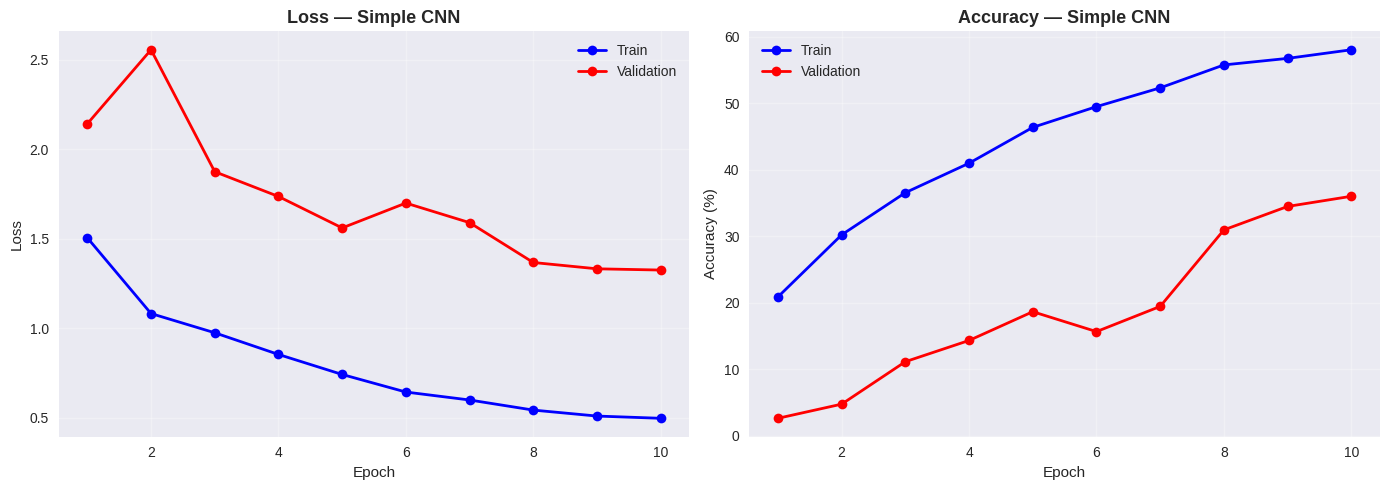

In [8]:
print("=" * 55)
print("🔷 ENTRAÎNEMENT SIMPLE CNN")
print("=" * 55)

criterion_cnn = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_cnn = optim.AdamW(simple_cnn.parameters(), lr=3e-4, weight_decay=1e-3)

NUM_EPOCHS_CNN = 10
scheduler_cnn  = optim.lr_scheduler.OneCycleLR(
    optimizer_cnn, max_lr=1e-3,
    steps_per_epoch=len(train_loader_cnn),
    epochs=NUM_EPOCHS_CNN
)
early_stop_cnn = EarlyStopping(patience=5)

train_losses_cnn, val_losses_cnn = [], []
train_accs_cnn,   val_accs_cnn   = [], []
best_acc_cnn = 0

for epoch in range(1, NUM_EPOCHS_CNN + 1):
    lr = optimizer_cnn.param_groups[0]['lr']
    print(f"\nEpoch {epoch}/{NUM_EPOCHS_CNN}  |  LR: {lr:.6f}")

    tr_loss, tr_acc = train_one_epoch_v2(
        simple_cnn, train_loader_cnn, criterion_cnn, optimizer_cnn, scheduler_cnn)
    vl_loss, vl_acc, _, _, _ = evaluate(simple_cnn, val_loader_cnn, criterion_cnn)

    train_losses_cnn.append(tr_loss); val_losses_cnn.append(vl_loss)
    train_accs_cnn.append(tr_acc);    val_accs_cnn.append(vl_acc)

    print(f"  Train → Loss: {tr_loss:.4f}  Acc: {tr_acc:.2f}%")
    print(f"  Val   → Loss: {vl_loss:.4f}  Acc: {vl_acc:.2f}%")

    if vl_acc > best_acc_cnn:
        best_acc_cnn = vl_acc
        torch.save(simple_cnn.state_dict(), 'best_simple_cnn.pth')
        print(f"  ✅ Nouveau meilleur CNN: {vl_acc:.2f}%")

    early_stop_cnn(vl_loss)
    if early_stop_cnn.early_stop:
        print(f"  ⏹️  Early stopping à l'epoch {epoch}")
        break

plot_curves(train_losses_cnn, val_losses_cnn, train_accs_cnn, val_accs_cnn, "Simple CNN")

## 🔶 Cellule 8 — Entraînement ResNet50 (Fine-tuning Progressif)

**Stratégie en 2 phases :**

| Phase | Couches entraînées | LR | Epochs |
|-------|-------------------|----|--------|
| 1 | Classifieur FC uniquement | 1e-3 | 2 |
| 2 | Classifieur + Layer4 | 1e-4 | 6 |

Cette approche évite de détruire les features pré-entraînées dès le début.



🔶 ENTRAÎNEMENT RESNET50 — FINE-TUNING PROGRESSIF

📌 Phase 1 — Classifieur uniquement (2 epochs)

Phase1 — Epoch 1/2  |  LR: 0.000040


  Train → Loss: 1.2148  Acc: 31.46%
  Val   → Loss: 1.8155  Acc: 11.92%
  ✅ Nouveau meilleur ResNet: 11.92%

Phase1 — Epoch 2/2  |  LR: 0.000808


  Train → Loss: 0.8291  Acc: 43.12%
  Val   → Loss: 1.5681  Acc: 14.51%
  ✅ Nouveau meilleur ResNet: 14.51%

📌 Phase 2 — Layer4 dégelé (6 epochs)

Phase2 — Epoch 1/6  |  LR: 0.000004


  Train → Loss: 0.6274  Acc: 48.77%
  Val   → Loss: 1.4028  Acc: 16.18%
  ✅ Nouveau meilleur ResNet: 16.18%

Phase2 — Epoch 2/6  |  LR: 0.000061


  Train → Loss: 0.3524  Acc: 62.77%
  Val   → Loss: 1.1104  Acc: 22.77%
  ✅ Nouveau meilleur ResNet: 22.77%

Phase2 — Epoch 3/6  |  LR: 0.000099


  Train → Loss: 0.2513  Acc: 70.53%
  Val   → Loss: 0.9478  Acc: 29.69%
  ✅ Nouveau meilleur ResNet: 29.69%

Phase2 — Epoch 4/6  |  LR: 0.000081


  Train → Loss: 0.2028  Acc: 75.19%
  Val   → Loss: 0.8132  Acc: 52.53%
  ✅ Nouveau meilleur ResNet: 52.53%

Phase2 — Epoch 5/6  |  LR: 0.000046


  Train → Loss: 0.1364  Acc: 81.24%
  Val   → Loss: 0.7437  Acc: 55.26%
  ✅ Nouveau meilleur ResNet: 55.26%

Phase2 — Epoch 6/6  |  LR: 0.000013


  Train → Loss: 0.1107  Acc: 82.70%
  Val   → Loss: 0.7544  Acc: 54.66%


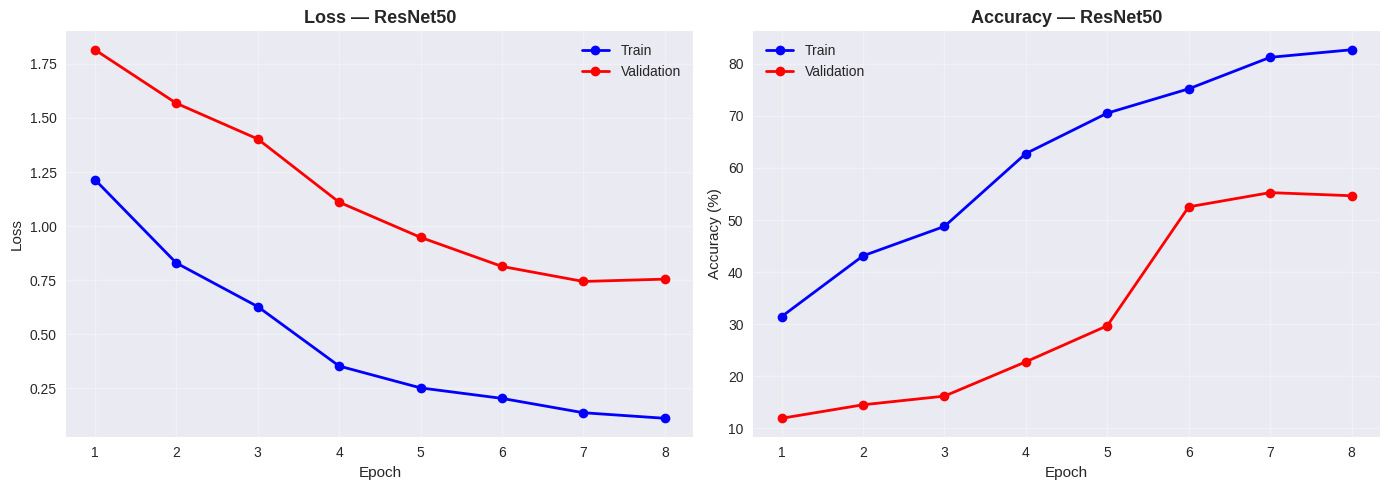

In [9]:
print("\n" + "=" * 55)
print("🔶 ENTRAÎNEMENT RESNET50 — FINE-TUNING PROGRESSIF")
print("=" * 55)

criterion_resnet  = nn.CrossEntropyLoss(weight=class_weights_tensor)
early_stop_resnet = EarlyStopping(patience=5)

train_losses_resnet, val_losses_resnet = [], []
train_accs_resnet,   val_accs_resnet   = [], []
best_acc_resnet = 0

# ── Phase 1 : classifieur uniquement (2 epochs, lr=1e-3) ──────────────────
print("\n📌 Phase 1 — Classifieur uniquement (2 epochs)")
optimizer_resnet = optim.AdamW(
    filter(lambda p: p.requires_grad, resnet50.parameters()),
    lr=1e-3, weight_decay=1e-4
)
scheduler_p1 = optim.lr_scheduler.OneCycleLR(
    optimizer_resnet, max_lr=1e-3,
    steps_per_epoch=len(train_loader_resnet), epochs=2
)

for epoch in range(1, 3):
    lr = optimizer_resnet.param_groups[0]['lr']
    print(f"\nPhase1 — Epoch {epoch}/2  |  LR: {lr:.6f}")
    tr_loss, tr_acc = train_one_epoch_v2(
        resnet50, train_loader_resnet, criterion_resnet, optimizer_resnet, scheduler_p1)
    vl_loss, vl_acc, _, _, _ = evaluate(resnet50, val_loader_resnet, criterion_resnet)

    train_losses_resnet.append(tr_loss); val_losses_resnet.append(vl_loss)
    train_accs_resnet.append(tr_acc);    val_accs_resnet.append(vl_acc)
    print(f"  Train → Loss: {tr_loss:.4f}  Acc: {tr_acc:.2f}%")
    print(f"  Val   → Loss: {vl_loss:.4f}  Acc: {vl_acc:.2f}%")

    if vl_acc > best_acc_resnet:
        best_acc_resnet = vl_acc
        torch.save(resnet50.state_dict(), 'best_resnet50.pth')
        print(f"  ✅ Nouveau meilleur ResNet: {vl_acc:.2f}%")

# ── Phase 2 : + layer4 dégelé (6 epochs, lr=1e-4) ─────────────────────────
print("\n📌 Phase 2 — Layer4 dégelé (6 epochs)")
resnet50.unfreeze_layer4()

optimizer_resnet2 = optim.AdamW(
    filter(lambda p: p.requires_grad, resnet50.parameters()),
    lr=1e-4, weight_decay=1e-4
)
NUM_P2 = 6
scheduler_p2 = optim.lr_scheduler.OneCycleLR(
    optimizer_resnet2, max_lr=1e-4,
    steps_per_epoch=len(train_loader_resnet), epochs=NUM_P2
)

for epoch in range(1, NUM_P2 + 1):
    lr = optimizer_resnet2.param_groups[0]['lr']
    print(f"\nPhase2 — Epoch {epoch}/{NUM_P2}  |  LR: {lr:.6f}")
    tr_loss, tr_acc = train_one_epoch_v2(
        resnet50, train_loader_resnet, criterion_resnet, optimizer_resnet2, scheduler_p2)
    vl_loss, vl_acc, _, _, _ = evaluate(resnet50, val_loader_resnet, criterion_resnet)

    train_losses_resnet.append(tr_loss); val_losses_resnet.append(vl_loss)
    train_accs_resnet.append(tr_acc);    val_accs_resnet.append(vl_acc)
    print(f"  Train → Loss: {tr_loss:.4f}  Acc: {tr_acc:.2f}%")
    print(f"  Val   → Loss: {vl_loss:.4f}  Acc: {vl_acc:.2f}%")

    if vl_acc > best_acc_resnet:
        best_acc_resnet = vl_acc
        torch.save(resnet50.state_dict(), 'best_resnet50.pth')
        print(f"  ✅ Nouveau meilleur ResNet: {vl_acc:.2f}%")

    early_stop_resnet(vl_loss)
    if early_stop_resnet.early_stop:
        print(f"  ⏹️  Early stopping à l'epoch {epoch}")
        break

plot_curves(train_losses_resnet, val_losses_resnet, train_accs_resnet, val_accs_resnet, "ResNet50")

## 🧪 Cellule 9 — Évaluation Finale sur le Test Set

In [10]:
print("\n" + "=" * 55)
print("🧪 ÉVALUATION FINALE SUR LE TEST SET")
print("=" * 55)

# Charger les meilleurs poids
simple_cnn.load_state_dict(torch.load('best_simple_cnn.pth'))
resnet50.load_state_dict(torch.load('best_resnet50.pth'))

_, cnn_test_acc,    cnn_preds,    cnn_labels,    cnn_probs    = evaluate(
    simple_cnn, test_loader_cnn,    criterion_cnn)
_, resnet_test_acc, resnet_preds, resnet_labels, resnet_probs = evaluate(
    resnet50,   test_loader_resnet, criterion_resnet)

print(f"\n🔷 Simple CNN  — Test Accuracy: {cnn_test_acc:.2f}%")
print(f"🔶 ResNet50    — Test Accuracy: {resnet_test_acc:.2f}%")

class_names_fr_list = [CLASS_NAMES_FR[cn] for cn in class_names]

print("\n📋 Rapport de classification — Simple CNN:")
print(classification_report(cnn_labels, cnn_preds,
                             target_names=class_names_fr_list, zero_division=0))

print("\n📋 Rapport de classification — ResNet50:")
print(classification_report(resnet_labels, resnet_preds,
                             target_names=class_names_fr_list, zero_division=0))


🧪 ÉVALUATION FINALE SUR LE TEST SET



🔷 Simple CNN  — Test Accuracy: 33.73%
🔶 ResNet50    — Test Accuracy: 54.62%

📋 Rapport de classification — Simple CNN:
                          precision    recall  f1-score   support

      Kératose actinique       0.18      0.80      0.29        49
Carcinome basocellulaire       0.40      0.38      0.39        77
        Kératose bénigne       0.34      0.23      0.28       165
          Dermatofibrome       0.04      0.71      0.07        17
                Mélanome       0.22      0.53      0.32       167
     Nævus mélanocytaire       1.00      0.28      0.44      1006
     Lésions vasculaires       0.17      0.91      0.29        22

                accuracy                           0.34      1503
               macro avg       0.34      0.55      0.30      1503
            weighted avg       0.76      0.34      0.39      1503


📋 Rapport de classification — ResNet50:
                          precision    recall  f1-score   support

      Kératose actinique       0.59      0.

## 🟦 Cellule 10 — Matrices de Confusion

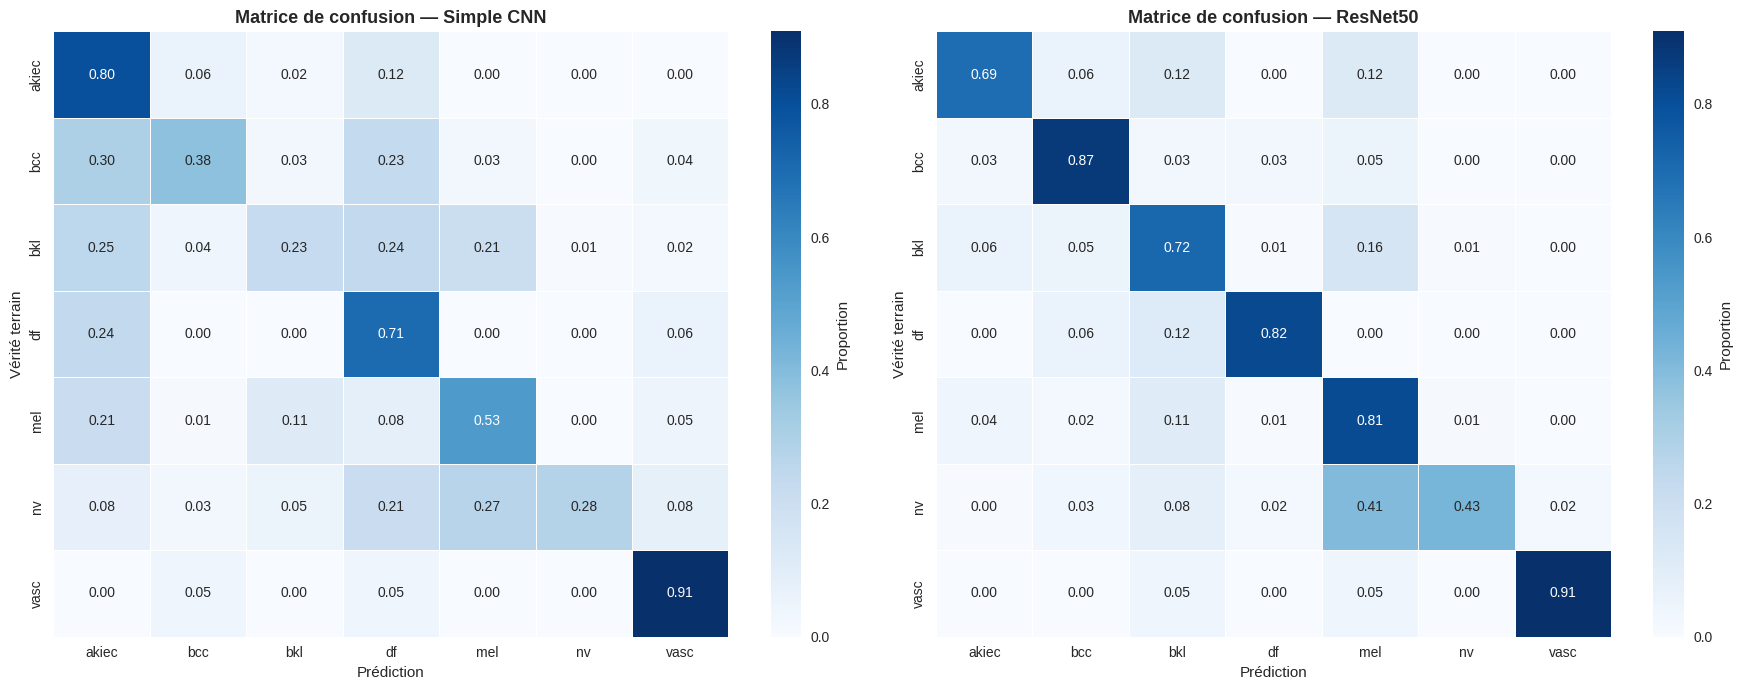

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
short_names = list(class_names)

for ax, preds, labels, title in [
    (axes[0], cnn_preds,    cnn_labels,    "Simple CNN"),
    (axes[1], resnet_preds, resnet_labels, "ResNet50"),
]:
    cm      = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=short_names, yticklabels=short_names, ax=ax,
                linewidths=0.5, cbar_kws={'label': 'Proportion'})
    ax.set_title(f'Matrice de confusion — {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Prédiction')
    ax.set_ylabel('Vérité terrain')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

## 📈 Cellule 11 — Courbes ROC (One-vs-Rest)

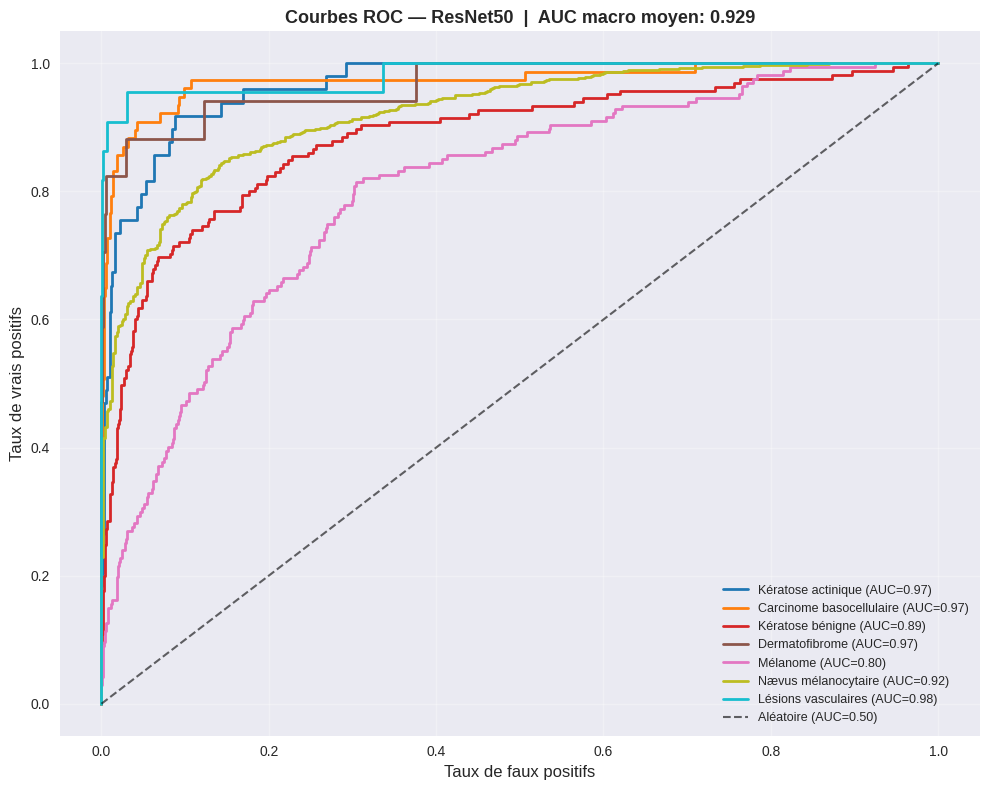

In [12]:
n_classes  = len(class_names)
y_test_bin = label_binarize(resnet_labels, classes=range(n_classes))

fig, ax = plt.subplots(figsize=(10, 8))
colors_roc = plt.cm.tab10(np.linspace(0, 1, n_classes))

mean_auc = 0
for i, (cn, color) in enumerate(zip(class_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], resnet_probs[:, i])
    roc_auc = auc(fpr, tpr)
    mean_auc += roc_auc
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{CLASS_NAMES_FR[cn]} (AUC={roc_auc:.2f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.6, label='Aléatoire (AUC=0.50)')
ax.set_xlabel('Taux de faux positifs', fontsize=12)
ax.set_ylabel('Taux de vrais positifs', fontsize=12)
ax.set_title(f'Courbes ROC — ResNet50  |  AUC macro moyen: {mean_auc/n_classes:.3f}',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

## 🔥 Cellule 12 — Grad-CAM (Attention Maps)

Grad-CAM visualise **quelles régions de l'image** le réseau utilise pour sa décision.  
- **Rouge/jaune** → zones importantes pour la prédiction  
- **Bleu** → zones peu influentes  


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


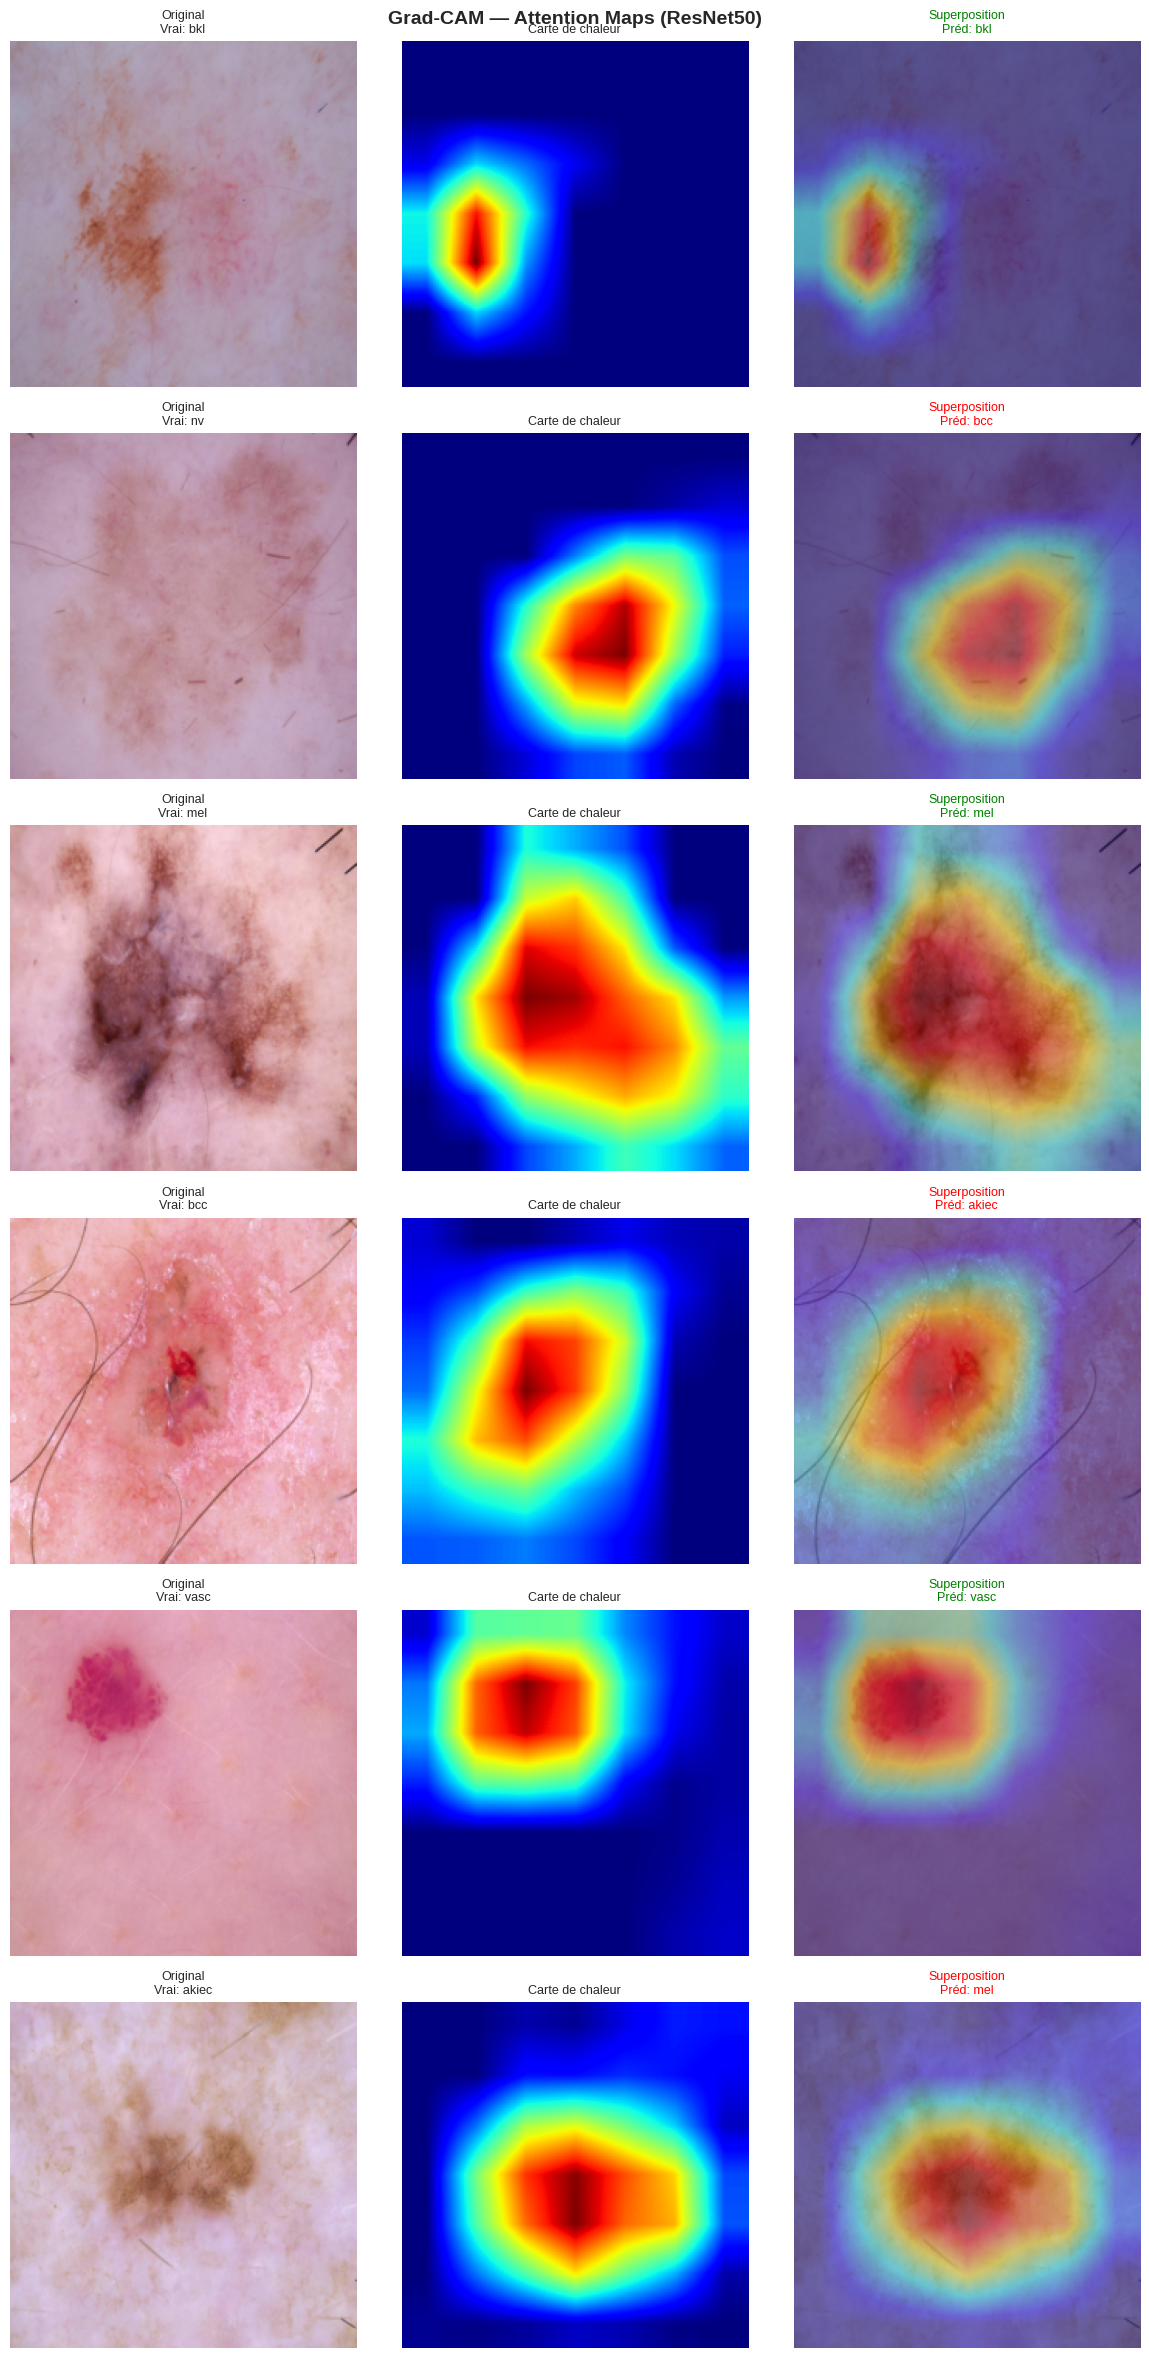

In [13]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.grads = None
        self.feats = None
        target_layer.register_forward_hook(self._save_feats)
        target_layer.register_backward_hook(self._save_grads)

    def _save_feats(self, _, __, output):
        self.feats = output

    def _save_grads(self, _, __, grad_out):
        self.grads = grad_out[0]

    def generate(self, x, class_idx=None):
        self.model.eval()
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(1).item()
        self.model.zero_grad()
        logits[0, class_idx].backward()
        weights = self.grads.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.feats).sum(dim=1, keepdim=True)
        cam = torch.relu(cam).squeeze().cpu().detach().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


gradcam  = GradCAM(resnet50, resnet50.resnet.layer4[-1])
mean_img = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std_img  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# Sélectionner 1 image par classe
sample_imgs, sample_lbls = [], []
for i in range(len(test_ds_resnet)):
    img, lbl = test_ds_resnet[i]
    if lbl not in sample_lbls:
        sample_imgs.append(img)
        sample_lbls.append(lbl)
    if len(sample_imgs) == min(6, n_classes):
        break

fig, axes = plt.subplots(len(sample_imgs), 3, figsize=(12, 4 * len(sample_imgs)))
fig.suptitle('Grad-CAM — Attention Maps (ResNet50)', fontsize=14, fontweight='bold')

for row, (img_t, true_lbl) in enumerate(zip(sample_imgs, sample_lbls)):
    x = img_t.unsqueeze(0).to(device)
    cam, pred_lbl = gradcam.generate(x)
    cam_resized = cv2.resize(cam, (224, 224))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.

    img_np  = (img_t * std_img + mean_img).permute(1, 2, 0).numpy().clip(0, 1)
    overlay = (0.5 * img_np + 0.4 * heatmap).clip(0, 1)

    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title(f"Original\nVrai: {class_names[true_lbl]}", fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(cam_resized, cmap='jet')
    axes[row, 1].set_title("Carte de chaleur", fontsize=9)
    axes[row, 1].axis('off')

    color = 'green' if pred_lbl == true_lbl else 'red'
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(
        f"Superposition\nPréd: {class_names[pred_lbl]}", fontsize=9, color=color)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig('gradcam.png', dpi=150)
plt.show()

## 🏁 Cellule 13 — Comparaison Finale & Conclusion


 COMPARAISON FINALE DES MODÈLES
                     Métrique Simple CNN   ResNet50
            Accuracy Test (%)      33.73      54.62
Meilleure Acc. Validation (%)      36.02      55.26
            Paramètres totaux    423,175 24,691,783
      Paramètres entraînables    423,175 16,148,487
                Taille entrée    128×128    224×224


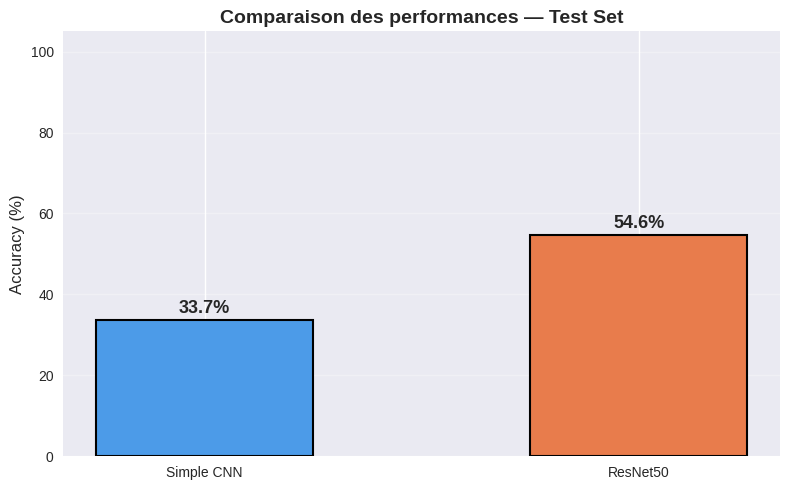


🏁 CONCLUSION
  ✅ ResNet50 surpasse Simple CNN de 20.89 points
  Raisons:
    • Transfer learning (pré-entraînement ImageNet)
    • Architecture plus profonde (50 couches vs 4)
    • Skip connections (gradient flow amélioré)
    • Fine-tuning progressif (phase 1 → phase 2)

💾 Résultats sauvegardés dans comparison_results.pkl


In [14]:
print("\n" + "=" * 60)
print(" COMPARAISON FINALE DES MODÈLES")
print("=" * 60)

cnn_p,    cnn_tp    = count_params(simple_cnn)
resnet_p, resnet_tp = count_params(resnet50)

comparison = pd.DataFrame({
    'Métrique': [
        'Accuracy Test (%)',
        'Meilleure Acc. Validation (%)',
        'Paramètres totaux',
        'Paramètres entraînables',
        'Taille entrée',
    ],
    'Simple CNN': [
        f"{cnn_test_acc:.2f}",
        f"{best_acc_cnn:.2f}",
        f"{cnn_p:,}",
        f"{cnn_tp:,}",
        "128×128",
    ],
    'ResNet50': [
        f"{resnet_test_acc:.2f}",
        f"{best_acc_resnet:.2f}",
        f"{resnet_p:,}",
        f"{resnet_tp:,}",
        "224×224",
    ],
})
print(comparison.to_string(index=False))

# Graphique barres
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    ['Simple CNN', 'ResNet50'],
    [cnn_test_acc, resnet_test_acc],
    color=['#4C9BE8', '#E87C4C'], edgecolor='black', linewidth=1.5, width=0.5
)
for bar, acc in zip(bars, [cnn_test_acc, resnet_test_acc]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_title('Comparaison des performances — Test Set', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150)
plt.show()

# Conclusion
delta = resnet_test_acc - cnn_test_acc
print("\n" + "=" * 60)
print("🏁 CONCLUSION")
print("=" * 60)
if delta > 0:
    print(f"  ✅ ResNet50 surpasse Simple CNN de {delta:.2f} points")
    print("  Raisons:")
    print("    • Transfer learning (pré-entraînement ImageNet)")
    print("    • Architecture plus profonde (50 couches vs 4)")
    print("    • Skip connections (gradient flow amélioré)")
    print("    • Fine-tuning progressif (phase 1 → phase 2)")
else:
    print(f"  ⚠️  Simple CNN ≥ ResNet50 (δ={delta:.2f}%)")
    print("  Causes possibles: surapprentissage ResNet, données insuffisantes")

# Sauvegarde des résultats
import pickle
results = dict(
    simple_cnn = dict(best_val_acc=best_acc_cnn,  test_acc=cnn_test_acc,
                      train_losses=train_losses_cnn, val_losses=val_losses_cnn,
                      train_accs=train_accs_cnn,     val_accs=val_accs_cnn),
    resnet50   = dict(best_val_acc=best_acc_resnet, test_acc=resnet_test_acc,
                      train_losses=train_losses_resnet, val_losses=val_losses_resnet,
                      train_accs=train_accs_resnet,     val_accs=val_accs_resnet),
)
with open('comparison_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print("\n💾 Résultats sauvegardés dans comparison_results.pkl")